In [70]:
import numpy as np
import pandas as pd
from itertools import product
from pulp import LpVariable, lpSum, value
from ortoolpy import model_min, addvars, addvals

In [71]:
df_tc = pd.read_csv('trans_cost.csv', index_col='工場')
df_tc.head()

,F1,F2,F3,F4
工場,,,,
W1,10,10,11,27
W2,18,21,12,14
W3,15,12,14,12


In [72]:
df_demand = pd.read_csv('demand.csv')
df_demand.head()

,F1,F2,F3,F4
0,28,29,31,25


In [73]:
df_supply = pd.read_csv('supply.csv')
df_supply.head()

,W1,W2,W3
0,35,41,42


In [74]:
nw = len(df_tc.index)
nf = len(df_tc.columns)
pr = list(product(range(nw), range(nf)))

m1 = model_min()
v1 = {(i, j) : LpVariable('v%d_%d'%(i, j), lowBound=0) for i, j in pr}

m1 += lpSum(df_tc.iloc[i][j] * v1[i, j] for i, j in pr)
for i in range(nw):
    m1 += lpSum(v1[i, j] for j in range(nf)) <= df_supply.iloc[0][i]
for j in range(nf):
    m1 += lpSum(v1[i, j] for i in range(nw)) >= df_demand.iloc[0][j]
m1.solve()

df_tr_sol = df_tc.copy()
total_cost = 0
for k, x in v1.items():
    i, j = k[0], k[1]
    df_tr_sol.iloc[i][j] = value(x)
    total_cost += df_tc.iloc[i][j] * value(x)

print(df_tr_sol)
print('総輸送コスト: ' + str(total_cost))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/takizawa/2025_takizawa/.venv/lib/python3.10/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/82ebaed541694b428ae0019da138d8ba-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/82ebaed541694b428ae0019da138d8ba-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 49 RHS
At line 57 BOUNDS
At line 58 ENDATA
Problem MODEL has 7 rows, 12 columns and 24 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 7 (0) rows, 12 (0) columns and 24 (0) elements
0  Obj 0 Primal inf 113 (4)
7  Obj 1296
Optimal - objective value 1296
Optimal objective 1296 - 7 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00   (Wallclock seconds):       0.00

    F1  F2  F3  F4
工場                
W1  28   7   0   0
W2   0   0  31   5
W3   0  22   

/tmp/ipykernel_23822/4072720744.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m1 += lpSum(df_tc.iloc[i][j] * v1[i, j] for i, j in pr)
/tmp/ipykernel_23822/4072720744.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m1 += lpSum(v1[i, j] for j in range(nf)) <= df_supply.iloc[0][i]
/tmp/ipykernel_23822/4072720744.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m1 += lpSum(v1[i, j] for i in range(nw)) >= df_demand.iloc[0]

In [75]:
df_tr = df_tr_sol.copy()
df_tr.head()

,F1,F2,F3,F4
工場,,,,
W1,28,7,0,0
W2,0,0,31,5
W3,0,22,0,20


In [76]:
df_pos = pd.read_csv('trans_route_pos.csv')
df_pos.head()

,W1,W2,W3,F1,F2,F3,F4
0,0,0,0,4.0,4.0,4.0,4.0
1,1,2,3,0.5,1.5,2.5,3.5


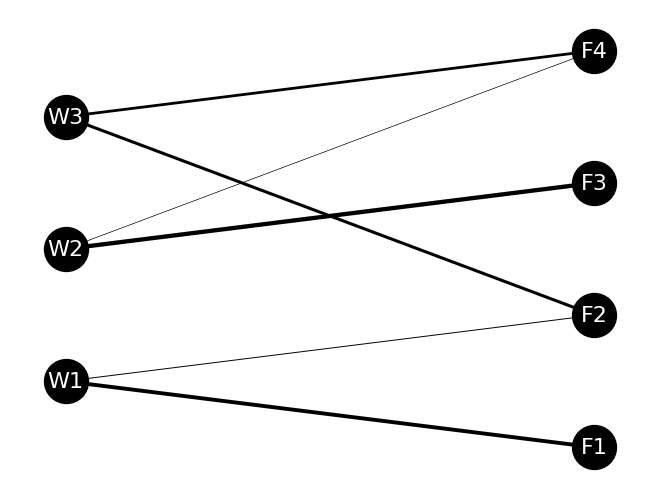

In [77]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

for i in range(len(df_pos.columns)):
    G.add_node(df_pos.columns[i])

num_pre = 0
edge_weights = []
size = 0.1
for i in range(len(df_pos.columns)):
    for j in range(len(df_pos.columns)):
        if not (i==j):

            G.add_edge(df_pos.columns[i], df_pos.columns[j])
            if num_pre < len(G.edges):
                num_pre = len(G.edges)
                weight = 0
                if (df_pos.columns[i] in df_tr.columns) and (df_pos.columns[j] in df_tr.index):
                    if df_tr[df_pos.columns[i]][df_pos.columns[j]]:
                        weight = df_tr[df_pos.columns[i]][df_pos.columns[j]] * size
                elif (df_pos.columns[j] in df_tr.columns) and (df_pos.columns[i] in df_tr.index):
                    if df_tr[df_pos.columns[j]][df_pos.columns[i]]:
                        weight = df_tr[df_pos.columns[j]][df_pos.columns[i]] * size
                edge_weights.append(weight)

pos = {}
for i in range(len(df_pos.columns)):
    node = df_pos.columns[i]
    pos[node] = (df_pos[node][0], df_pos[node][1])

nx.draw(G, pos, with_labels=True, font_size=16, node_size=1000, node_color='k', font_color='w', width=edge_weights)
plt.show()

In [78]:
df_demand.head()

,F1,F2,F3,F4
0,28,29,31,25


In [79]:
df_supply.head()

,W1,W2,W3
0,35,41,42


In [80]:
def condition_demand(df_tr, df_demand):
    flag = np.zeros(len(df_demand.columns))
    for i in range(len(df_demand.columns)):
        temp_sum = sum(df_tr[df_demand.columns[i]])
        if (temp_sum >= df_demand.iloc[0][i]):
            flag[i] = 1
    return flag

def condition_supply(df_tr, df_supply):
    flag = np.zeros(len(df_supply.columns))
    for i in range(len(df_supply.columns)):
        temp_sum = sum(df_tr.loc[df_supply.columns[i]])
        if temp_sum <= df_supply.iloc[0][i]:
            flag[i] = 1
    return flag 

print('需要条件計算結果: ' + str(condition_demand(df_tr_sol, df_demand)))
print('供給条件計算結果: ' + str(condition_supply(df_tr_sol, df_supply)))

需要条件計算結果: [1. 1. 1. 1.]
供給条件計算結果: [1. 1. 1.]


/tmp/ipykernel_23822/4015473406.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (temp_sum >= df_demand.iloc[0][i]):
/tmp/ipykernel_23822/4015473406.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if temp_sum <= df_supply.iloc[0][i]:


In [81]:
df_material = pd.read_csv('product_plan_material.csv', index_col='製品')
df_material.head()

,原料1,原料2,原料3
製品,,,
製品1,1,4,3
製品2,2,4,1


In [82]:
df_profit = pd.read_csv('product_plan_profit.csv', index_col='製品')
df_profit.head()

,利益
製品,
製品1,5.0
製品2,4.0


In [83]:
df_stock = pd.read_csv('product_plan_stock.csv', index_col='項目')
df_stock.head()

,原料1,原料2,原料3
項目,,,
在庫,40,80,50


In [84]:
df_plan = pd.read_csv('product_plan.csv', index_col='製品')
df_plan.head()

,生産量
製品,
製品1,16
製品2,0


In [85]:
# 利益計算関数
def product_plan(df_profit, df_plan):
    profit = 0
    for i in range(len(df_profit.index)):
        for j in range(len(df_plan.columns)):
            profit += df_profit.iloc[i][j] * df_plan.iloc[i][j]
    return profit

print('総利益: ' + str(product_plan(df_profit, df_plan)))

総利益: 80.0


/tmp/ipykernel_23822/3007574374.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  profit += df_profit.iloc[i][j] * df_plan.iloc[i][j]


In [86]:
from pulp import LpVariable, lpSum, value
from ortoolpy import model_max, addvars, addvals

df = df_material.copy()
inv = df_stock

m = model_max()
v1 = {(i) : LpVariable('v%d'%(i), lowBound=0) for i in range(len(df_profit))}

m += lpSum(df_profit.iloc[i] * v1[i] for i in range(len(df_profit)))
for i in range(len(df_material.columns)):
    m += lpSum(df_material.iloc[j, i] * v1[j] for j in range(len(df_profit))) <= df_stock.iloc[:, i]
m.solve()

df_plan_sol = df_plan.copy()
for k, x in v1.items():
    df_plan_sol.iloc[k] = value(x)
print(df_plan_sol)
print('総利益: ' + str(value(m.objective)))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/takizawa/2025_takizawa/.venv/lib/python3.10/site-packages/pulp/solverdir/cbc/linux/64/cbc /tmp/0b6b83a308cc4d67889245286bbe4f90-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /tmp/0b6b83a308cc4d67889245286bbe4f90-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 17 RHS
At line 21 BOUNDS
At line 22 ENDATA
Problem MODEL has 3 rows, 2 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 3 (0) rows, 2 (0) columns and 6 (0) elements
0  Obj -0 Dual inf 8.9999998 (2)
0  Obj -0 Dual inf 8.9999998 (2)
2  Obj 95
Optimal - objective value 95
Optimal objective 95 - 2 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.00   (Wallclock seconds):       0.00

     生産量
製品      
製品1   15
製品2    5
総利益: 95.0


In [87]:
# 制約条件計算関数

def condition_stock(df_plan, df_material, df_stock):
    flag = np.zeros(len(df_material.columns))
    for i in range(len(df_material.columns)):
        temp_sum = 0
        for j in range(len(df_material.index)):
            temp_sum = temp_sum + df_material.iloc[j][i] * float(df_plan.iloc[j])
        if (temp_sum <= float(df_stock.iloc[0][i])):
            flag[i] = 1
        print(df_material.columns[i] + ' 使用料: ' + str(temp_sum) + ', 在庫: ' + str(float(df_stock.iloc[0][i])))
    return flag

print('制約条件計算結果: ' + str(condition_stock(df_plan_sol, df_material, df_stock)))

原料1 使用料: 25.0, 在庫: 40.0
原料2 使用料: 80.0, 在庫: 80.0
原料3 使用料: 50.0, 在庫: 50.0
制約条件計算結果: [1. 1. 1.]


/tmp/ipykernel_23822/2813282795.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_sum = temp_sum + df_material.iloc[j][i] * float(df_plan.iloc[j])
/tmp/ipykernel_23822/2813282795.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  temp_sum = temp_sum + df_material.iloc[j][i] * float(df_plan.iloc[j])
/tmp/ipykernel_23822/2813282795.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (temp_sum <= float(df_stock.iloc[0][i])):
/tmp/ipykernel_23822/2813282795.py:11: FutureWarning: Series.__getitem__ treating keys a

In [92]:
製品 = list('AB')
需要地 = list('PQ')
工場 = list('XY')
レーン = (2, 2)

# 輸送費表
tbdi = pd.DataFrame(((j, k) for j in 需要地 for k in 工場), columns=['需要地', '工場'])
tbdi['輸送費'] = [1, 2, 3, 1]
print(tbdi)

# 需要表
tbde = pd.DataFrame(((j, i) for j in 需要地 for i in 製品), columns=['需要地', '製品'])
tbde['需要'] = [10, 10, 20, 20]
print(tbde)

# 生産表
tbfa = pd.DataFrame(((k, l, i, 0, np.inf) for k, nl in zip(工場, レーン) for l in range(nl) for i in 製品), columns=['工場', 'レーン', '製品', '下限', '上限'])
tbfa['生産費'] = [1, np.nan, np.nan, 1, 3, np.nan, 5, 3]
tbfa.dropna(inplace=True)
tbfa.loc[4, '上限'] = 10
print(tbfa)

from ortoolpy import logistics_network
_, tbdi2, _ = logistics_network(tbde, tbdi, tbfa)
print(tbfa)
print(tbdi2)

  需要地 工場  輸送費
0   P  X    1
1   P  Y    2
2   Q  X    3
3   Q  Y    1
  需要地 製品  需要
0   P  A  10
1   P  B  10
2   Q  A  20
3   Q  B  20
  工場  レーン 製品  下限    上限  生産費
0  X    0  A   0   inf  1.0
3  X    1  B   0   inf  1.0
4  Y    0  A   0  10.0  3.0
6  Y    1  A   0   inf  5.0
7  Y    1  B   0   inf  3.0


TypeError: concat() takes 1 positional argument but 2 were given